# Introduction to Matplotlib

## Visualization with Matplotlib

### General Matplotlib Tips

- Before we dive into the details of creating visualizations with Matplotlib, there are a few useful things you should know about using the package.

#### Importing Matplotlib

- Just as we use the np shorthand for NumPy and the pd shorthand for Pandas, we will use some standard shorthands for Matplotlib imports:

In [1]:
import matplotlib.pyplot as plt

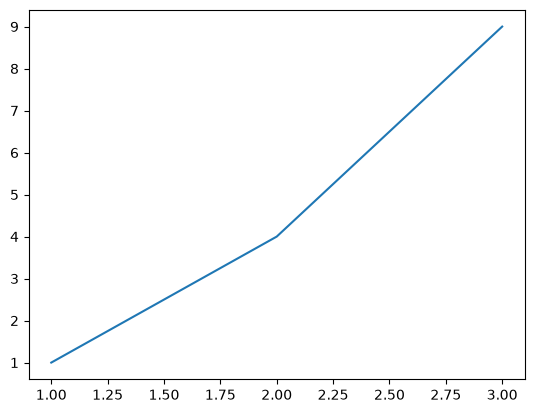

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [8]:
df = pd.read_csv('./data/Superstore (1).csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3.0,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.isnull().sum()

Row ID           194
Order ID         194
Order Date       194
Ship Date        194
Ship Mode        194
Customer ID      194
Customer Name    194
Segment          194
Country          194
City             194
State            194
Postal Code      205
Region           194
Product ID       194
Category         194
Sub-Category     194
Product Name     194
Sales            194
Quantity           0
Discount           0
Profit             0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Single Variable (Univariate)

#### Matlab Style Interface

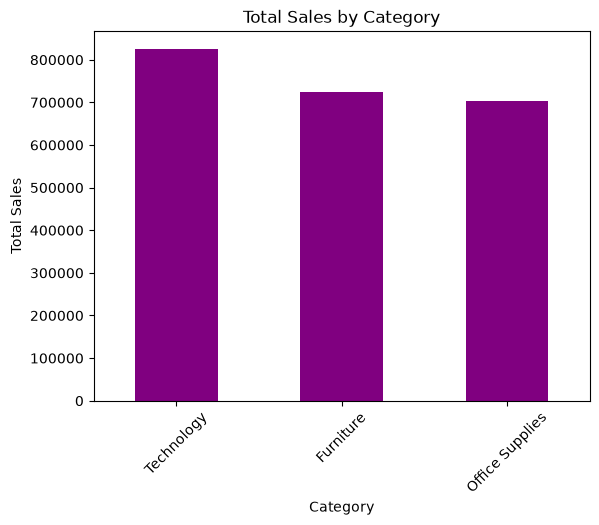

In [35]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sales_by_category.plot(kind='bar', color='purple')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

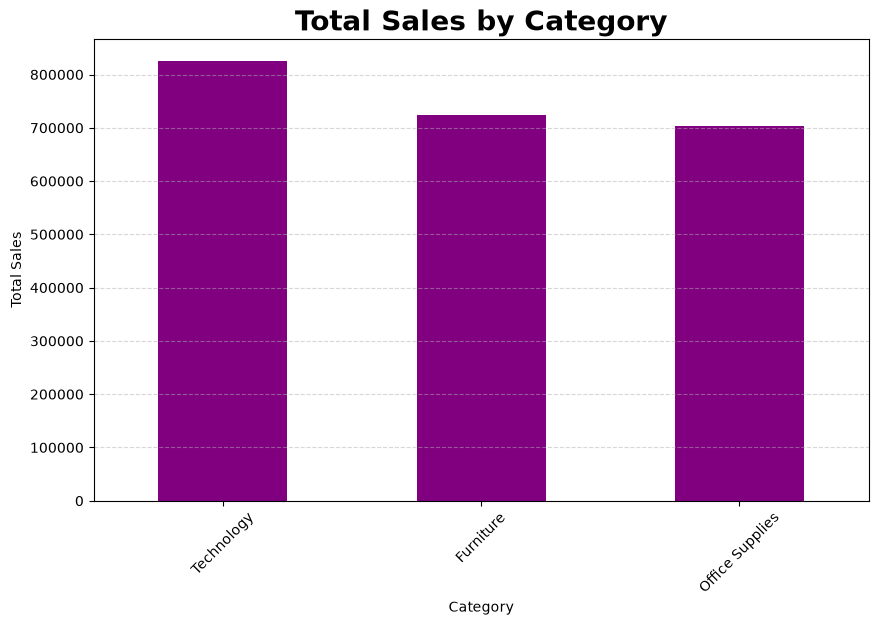

In [36]:
sales_by_category

fig, ax = plt.subplots(figsize=(10, 6))

ax = sales_by_category.plot(kind='bar', color='purple')

ax.set_title('Total Sales by Category', fontsize=20, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales')

#  adding gridlines
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.show()

### Sales by Segment - Pie Chart

<Axes: >

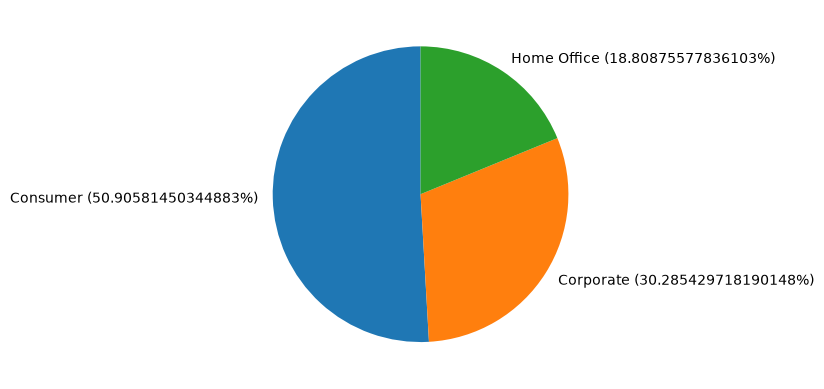

In [42]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

total = sales_by_segment.sum()
percentages = (sales_by_segment / total) * 100
percentages

# build the custom labels
labels = [f'{seg} ({pct}%)' for seg, pct in zip(sales_by_segment.index, percentages)]

sales_by_segment.plot(
    kind='pie',
    startangle=90,
    labels=labels,
)